Install Packages

In [2]:
!pip -q install imbalanced-learn

Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

Mounting Google Drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


Loading Dataset from Google Drive

In [5]:
DATA_PATH = "/content/drive/MyDrive/creditcard.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Basic Cleaning

In [6]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()
print("Shape after dropping duplicates:", df.shape)

Missing values:
 0
Duplicate rows: 1081
Shape after dropping duplicates: (283726, 31)


Outliner Treatment on Amount

In [7]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Amount_capped"] = np.clip(df["Amount"], lower, upper)

print("Amount outlier handling completed")
df[["Amount", "Amount_capped"]].head()

Amount outlier handling completed


,Amount,Amount_capped
0,149.62,149.620
1,2.69,2.690
2,378.66,185.375
3,123.50,123.500
4,69.99,69.990


Real-world feature engineering

In [8]:
df_new = df.copy()

# Use capped amount as main working amount
df_new["Amount"] = df_new["Amount_capped"]

# Existing features
df_new["transaction_hour"] = (df_new["Time"] / 3600) % 24
df_new["is_night_transaction"] = df_new["transaction_hour"].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

high_amount_threshold = df_new["Amount"].quantile(0.95)
df_new["is_high_amount"] = (df_new["Amount"] > high_amount_threshold).astype(int)

median_amount = df_new["Amount"].median()
mean_amount = df_new["Amount"].mean()
very_high_amount_threshold = df_new["Amount"].quantile(0.99)

df_new["amount_to_median_ratio"] = df_new["Amount"] / (median_amount + 1e-6)
df_new["amount_deviation_from_mean"] = df_new["Amount"] - mean_amount
df_new["amount_log"] = np.log1p(df_new["Amount"])
df_new["risk_amount_flag"] = (df_new["Amount"] > very_high_amount_threshold).astype(int)

# Advanced features
df_new["amount_percentile"] = df_new["Amount"].rank(pct=True)

rolling_mean = df_new["Amount"].rolling(window=10, min_periods=1).mean()
df_new["amount_spike"] = df_new["Amount"] / (rolling_mean + 1e-6)

df_new["high_risk_combo"] = (
    (df_new["is_high_amount"] == 1) &
    (df_new["is_night_transaction"] == 1)
).astype(int)

df_new["amount_squared"] = df_new["Amount"] ** 2
df_new["log_time"] = np.log1p(df_new["Time"])
df_new["time_amount_interaction"] = df_new["transaction_hour"] * df_new["Amount"]

df_new[[
    "Time", "Amount", "transaction_hour", "is_night_transaction",
    "is_high_amount", "amount_to_median_ratio",
    "amount_deviation_from_mean", "amount_log",
    "risk_amount_flag", "amount_percentile",
    "amount_spike", "high_risk_combo",
    "amount_squared", "log_time", "time_amount_interaction"
]].head()

,Time,Amount,transaction_hour,is_night_transaction,is_high_amount,amount_to_median_ratio,amount_deviation_from_mean,amount_log,risk_amount_flag,amount_percentile,amount_spike,high_risk_combo,amount_squared,log_time,time_amount_interaction
0,0.0,149.620,0.000000,1,0,6.800909,97.7268,5.014760,0,0.859116,1.000000,0,22386.144400,0.000000,0.000000
1,0.0,2.690,0.000000,1,0,0.122273,-49.2032,1.305626,0,0.185131,0.035323,0,7.236100,0.000000,0.000000
2,1.0,185.375,0.000278,1,0,8.426136,133.4818,5.227761,0,0.944164,1.646875,0,34363.890625,0.693147,0.051493
3,1.0,123.500,0.000278,1,0,5.613636,71.6068,4.824306,0,0.831998,1.071154,0,15252.250000,0.693147,0.034306
4,2.0,69.990,0.000556,1,0,3.181363,18.0968,4.262539,0,0.730608,0.658822,0,4898.600100,1.098612,0.038883


Building X and Y, Cleaning NaN

In [9]:
X_new = df_new.drop(columns=["Class", "Amount_capped"], errors="ignore")
y_new = df_new["Class"]

X_new = X_new.replace([np.inf, -np.inf], np.nan)
X_new = X_new.fillna(X_new.median(numeric_only=True))

print("Updated features shape:", X_new.shape)
print("Target shape:", y_new.shape)
print("Remaining NaN values:", X_new.isnull().sum().sum())
print("Remaining infinite values:", np.isinf(X_new).sum().sum())

Updated features shape: (283726, 43)
Target shape: (283726,)
Remaining NaN values: 0
Remaining infinite values: 0


Spliting Dataset

In [10]:
X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.30, random_state=42, stratify=y_new
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.50, random_state=42, stratify=y_temp_new
)

print("Training set:", X_train_new.shape)
print("Validation set:", X_val_new.shape)
print("Test set:", X_test_new.shape)

Training set: (198608, 43)
Validation set: (42559, 43)
Test set: (42559, 43)


Scaling Features

In [11]:
scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_val_scaled_new = scaler_new.transform(X_val_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

print("Scaling completed")

Scaling completed


Class Distribution (Imbalance Proof)

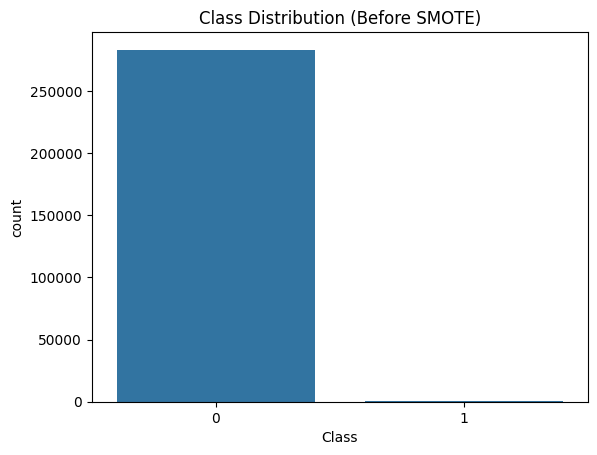

In [12]:
plt.figure()
sns.countplot(x=y_new)
plt.title("Class Distribution (Before SMOTE)")
plt.show()

Applying SMOTE

In [13]:
smote = SMOTE(random_state=42)

X_train_smote_new, y_train_smote_new = smote.fit_resample(
    X_train_scaled_new, y_train_new
)

print("After SMOTE:", X_train_smote_new.shape)

After SMOTE: (396554, 43)


After SMOTE

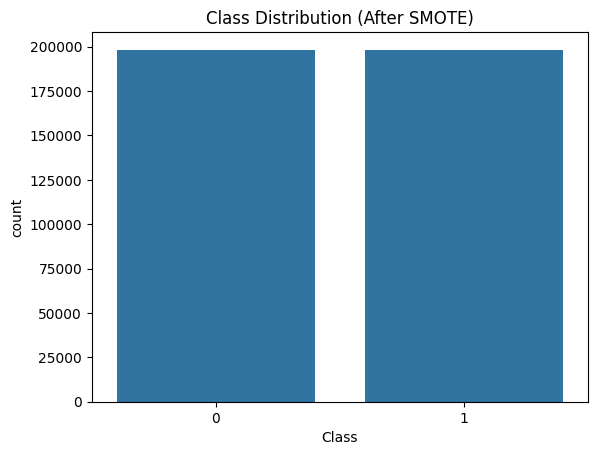

In [14]:
plt.figure()
sns.countplot(x=y_train_smote_new)
plt.title("Class Distribution (After SMOTE)")
plt.show()

Enchancing Random Forest

In [15]:
best_rf_new = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

best_rf_new.fit(X_train_smote_new, y_train_smote_new)
y_pred_rf = best_rf_new.predict(X_test_scaled_new)

print("Confusion Matrix (Enhanced Random Forest):")
print(confusion_matrix(y_test_new, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_rf))

print("\nROC-AUC Score:")
rf_auc = roc_auc_score(y_test_new, y_pred_rf)
print(rf_auc)

Confusion Matrix (Enhanced Random Forest):
[[42482     6]
 [   15    56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.90      0.79      0.84        71

    accuracy                           1.00     42559
   macro avg       0.95      0.89      0.92     42559
weighted avg       1.00      1.00      1.00     42559


ROC-AUC Score:
0.8942955890113795


Real-world feature importance

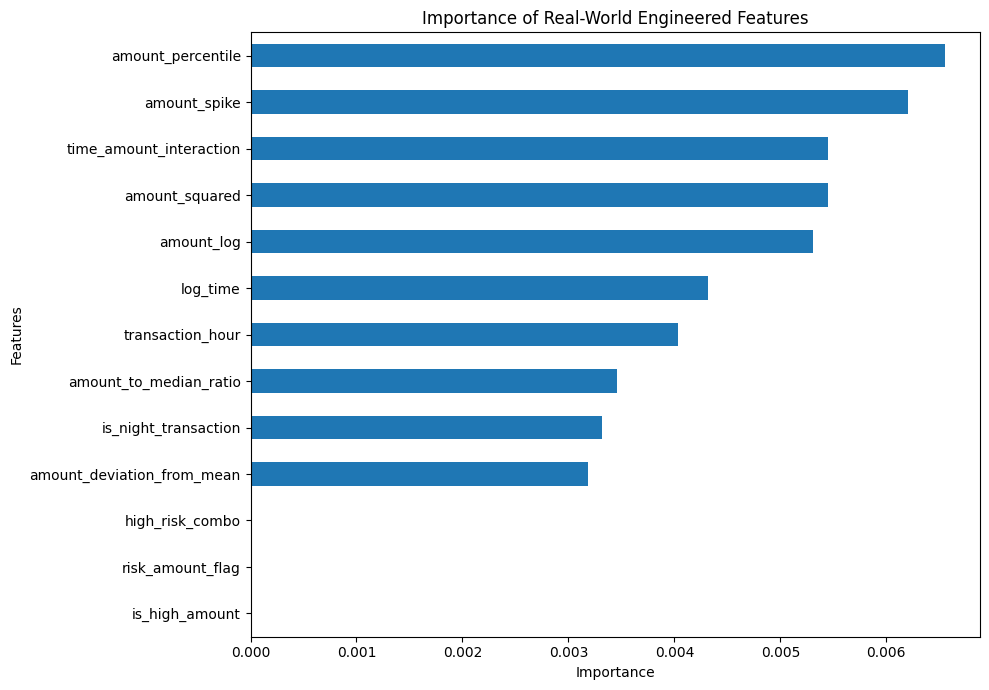

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)

real_world_features = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag",
    "amount_percentile",
    "amount_spike",
    "high_risk_combo",
    "amount_squared",
    "log_time",
    "time_amount_interaction"
]

real_world_importance = feature_importance_new[
    feature_importance_new.index.isin(real_world_features)
].sort_values(ascending=True)

plt.figure(figsize=(10, 7))
real_world_importance.plot(kind="barh")
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Confusion Matrix heatmap for Enhanced RF

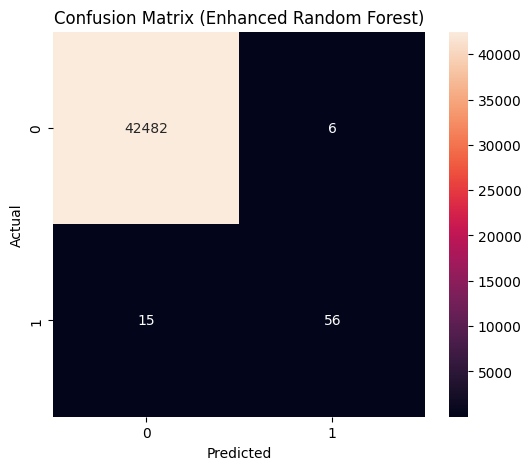

In [17]:
cm_rf = confusion_matrix(y_test_new, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confusion Matrix (Enhanced Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC curve from Enhanced RF

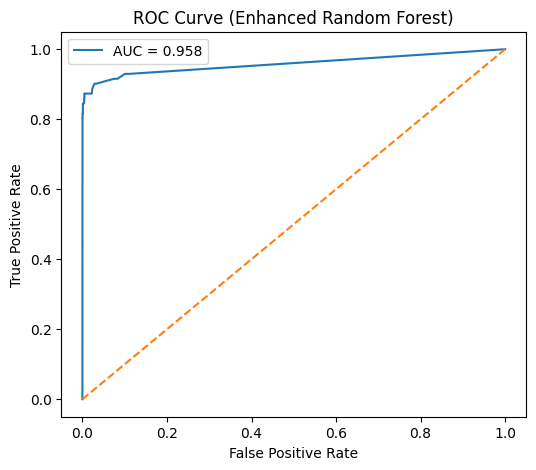

In [18]:
y_prob_rf = best_rf_new.predict_proba(X_test_scaled_new)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_new, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test_new, y_prob_rf):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (Enhanced Random Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

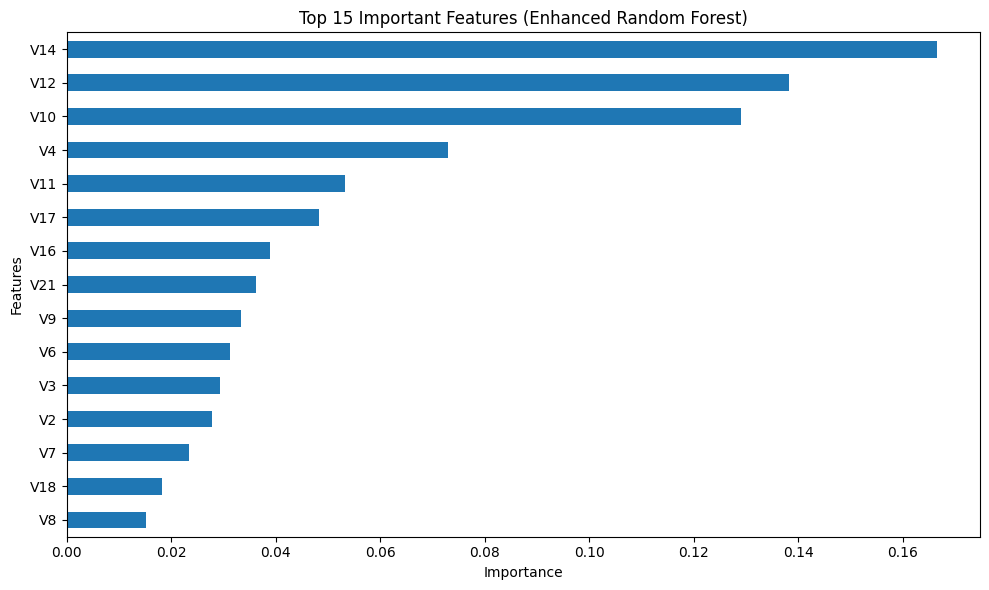

In [19]:
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)
top_features_new = feature_importance_new.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features_new.sort_values().plot(kind="barh")
plt.title("Top 15 Important Features (Enhanced Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

K-Fold Validation for Random Forest

In [20]:
rf_cv_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=50,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features='log2',
        max_depth=30,
        class_weight='balanced',
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_cv_pipeline,
    X_new,
    y_new,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

print("K-Fold Recall Scores:", cv_scores)
print("Mean Recall:", np.mean(cv_scores))
print("Std Recall:", np.std(cv_scores))

K-Fold Recall Scores: [0.83157895 0.80851064 0.76595745 0.83157895 0.83157895]
Mean Recall: 0.8138409854423292
Std Recall: 0.02555445852547563


After K-Fold Validation Plot

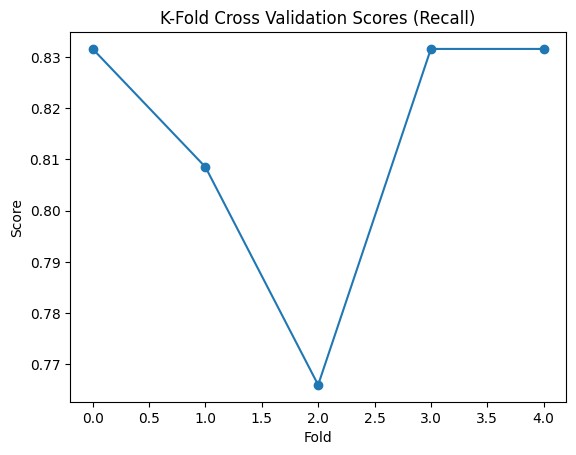

In [21]:
plt.figure()
plt.plot(cv_scores, marker='o')
plt.title("K-Fold Cross Validation Scores (Recall)")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.show()

Isolation Forest trained on normal transactions only

In [22]:
X_train_normal = X_train_scaled_new[y_train_new == 0]

iso_model = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso_model.fit(X_train_normal)

y_pred_iso = iso_model.predict(X_test_scaled_new)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("Confusion Matrix (Isolation Forest):")
print(confusion_matrix(y_test_new, y_pred_iso))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_iso))

print("\nROC-AUC Score:")
iso_auc = roc_auc_score(y_test_new, y_pred_iso)
print(iso_auc)

Confusion Matrix (Isolation Forest):
[[42395    93]
 [   52    19]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.17      0.27      0.21        71

    accuracy                           1.00     42559
   macro avg       0.58      0.63      0.60     42559
weighted avg       1.00      1.00      1.00     42559


ROC-AUC Score:
0.6327083902397628


ROC curve for Isolation Forest

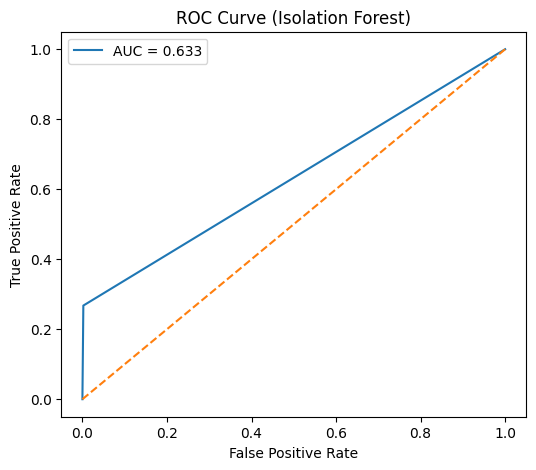

In [23]:
fpr_iso, tpr_iso, _ = roc_curve(y_test_new, y_pred_iso)

plt.figure(figsize=(6, 5))
plt.plot(fpr_iso, tpr_iso, label=f"AUC = {iso_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (Isolation Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Local Outliner Factor LOF

In [24]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017,
    novelty=True
)

lof_model.fit(X_train_normal)

y_pred_lof = lof_model.predict(X_test_scaled_new)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

print("Confusion Matrix (LOF):")
print(confusion_matrix(y_test_new, y_pred_lof))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_lof))

print("\nROC-AUC Score:")
lof_auc = roc_auc_score(y_test_new, y_pred_lof)
print(lof_auc)

Confusion Matrix (LOF):
[[42418    70]
 [   70     1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.01      0.01      0.01        71

    accuracy                           1.00     42559
   macro avg       0.51      0.51      0.51     42559
weighted avg       1.00      1.00      1.00     42559


ROC-AUC Score:
0.5062184915177376


LOF ROC Curve

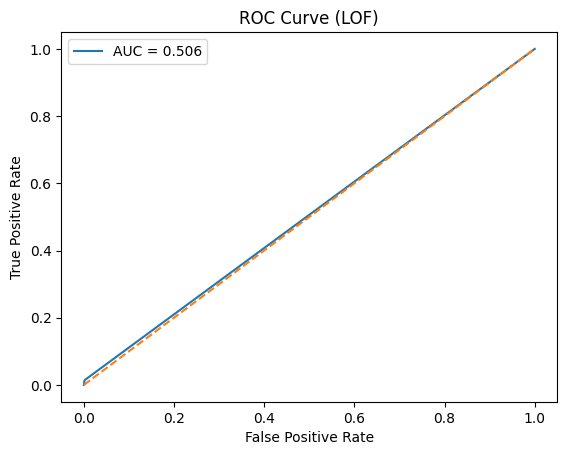

In [25]:
fpr_lof, tpr_lof, _ = roc_curve(y_test_new, y_pred_lof)

plt.figure()
plt.plot(fpr_lof, tpr_lof, label=f"AUC = {lof_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve (LOF)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

MLP

In [26]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42
)

mlp_model.fit(X_train_smote_new, y_train_smote_new)
y_pred_mlp = mlp_model.predict(X_test_scaled_new)

print("Confusion Matrix (MLP):")
print(confusion_matrix(y_test_new, y_pred_mlp))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_mlp))

print("\nROC-AUC Score:")
mlp_auc = roc_auc_score(y_test_new, y_pred_mlp)
print(mlp_auc)

Confusion Matrix (MLP):
[[42477    11]
 [   16    55]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.83      0.77      0.80        71

    accuracy                           1.00     42559
   macro avg       0.92      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559


ROC-AUC Score:
0.8871944953471534


MLP ROC Curve Deep Learning Proof

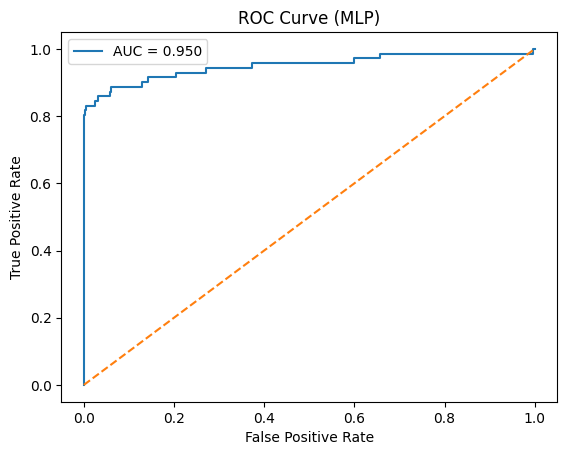

In [27]:
y_prob_mlp = mlp_model.predict_proba(X_test_scaled_new)[:, 1]

fpr_mlp, tpr_mlp, _ = roc_curve(y_test_new, y_prob_mlp)

plt.figure()
plt.plot(fpr_mlp, tpr_mlp, label=f"AUC = {roc_auc_score(y_test_new, y_prob_mlp):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve (MLP)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Model Comparison table

In [28]:
comparison_df = pd.DataFrame({
    "Model": [
        "Enhanced Random Forest",
        "Isolation Forest",
        "LOF",
        "MLP"
    ],
    "ROC_AUC": [rf_auc, iso_auc, lof_auc, mlp_auc]
})

comparison_df

,Model,ROC_AUC
0,Enhanced Random Forest,0.894296
1,Isolation Forest,0.632708
2,LOF,0.506218
3,MLP,0.887194


In [29]:
import joblib

joblib.dump(best_rf_new, "fraud_model.pkl")
joblib.dump(scaler_new, "scaler_new.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


Model Comparision Graph

<Figure size 800x500 with 0 Axes>

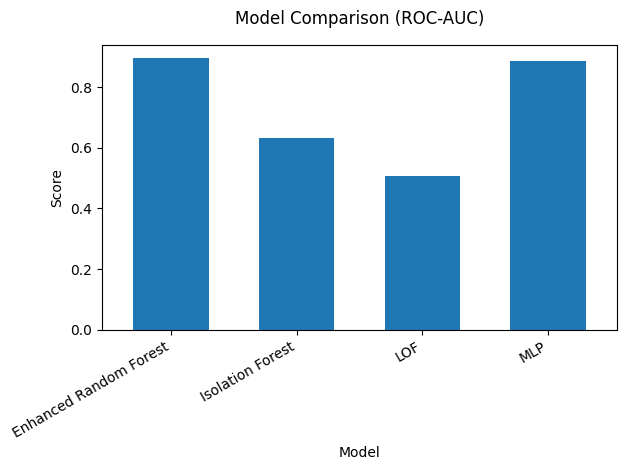

In [30]:
plt.figure(figsize=(8, 5))

ax = comparison_df.set_index("Model").plot(
    kind="bar",
    legend=False,
    width=0.6
)

plt.title("Model Comparison (ROC-AUC)", pad=15)
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=30, ha='right')  # better alignment
plt.tight_layout()  # 🔥 fixes centering

plt.show()

# Autoencoder

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [32]:
# Train Autoencoder only on normal transactions
X_train_normal = X_train_scaled_new[y_train_new == 0]

print("Normal training data shape:", X_train_normal.shape)
print("Test data shape:", X_test_scaled_new.shape)

Normal training data shape: (198277, 43)
Test data shape: (42559, 43)


Autoencoder Model

In [33]:
input_dim = X_train_normal.shape[1]
encoding_dim = 16

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 43)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,899 (15.23 KB)

 Trainable params: 3,899 (15.23 KB)

 Non-trainable params: 0 (0.00 B)

Training Autoencoder

In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.5252 - val_loss: 0.3706
Epoch 2/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3107 - val_loss: 0.2807
Epoch 3/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2570 - val_loss: 0.2520
Epoch 4/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2364 - val_loss: 0.2355
Epoch 5/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2238 - val_loss: 0.2234
Epoch 6/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2126 - val_loss: 0.2114
Epoch 7/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2008 - val_loss: 0.2009
Epoch 8/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1892 - val_loss: 0.1883
Epoch 9/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1783 - val_loss: 0.1900
Epoch 10/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1688 - val_loss: 0.1664
Epoch 11/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1589 - val_loss: 0.1555
Epoch 12/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Plot training loss

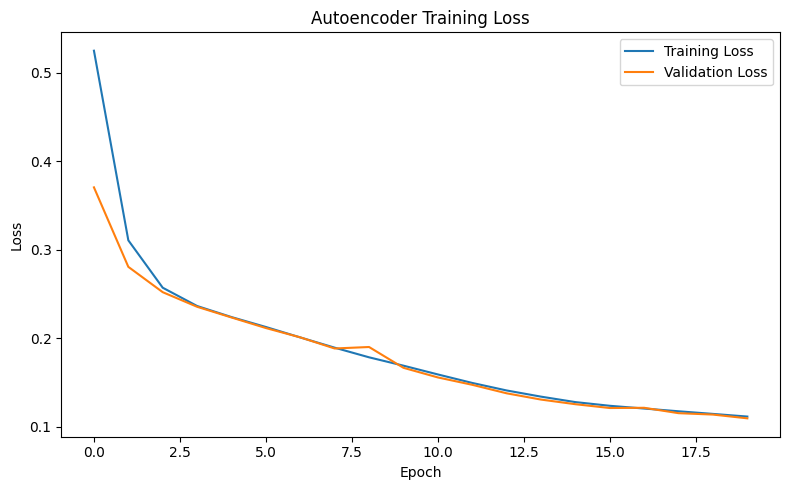

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Evalutation reconstruction error

In [36]:
# Reconstruct test data
X_test_reconstructed = autoencoder.predict(X_test_scaled_new)

# Reconstruction error on test data
mse = np.mean(np.power(X_test_scaled_new - X_test_reconstructed, 2), axis=1)

# Reconstruction error on normal training data
X_train_reconstructed = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - X_train_reconstructed, 2), axis=1)

# Threshold from normal training reconstruction error
threshold = np.percentile(train_mse, 95)

print("Reconstruction threshold:", threshold)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
Reconstruction threshold: 0.35189051942757743


Conversion of error into fraud predictions

In [37]:
y_pred_ae = (mse > threshold).astype(int)

print("Confusion Matrix (Autoencoder):")
print(confusion_matrix(y_test_new, y_pred_ae))

print("\nClassification Report (Autoencoder):")
print(classification_report(y_test_new, y_pred_ae))

print("\nROC-AUC Score:")
ae_auc = roc_auc_score(y_test_new, y_pred_ae)
print(ae_auc)

Confusion Matrix (Autoencoder):
[[40330  2158]
 [   12    59]]

Classification Report (Autoencoder):
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     42488
           1       0.03      0.83      0.05        71

    accuracy                           0.95     42559
   macro avg       0.51      0.89      0.51     42559
weighted avg       1.00      0.95      0.97     42559


ROC-AUC Score:
0.8900975519848521


Confusion matrix heatmap

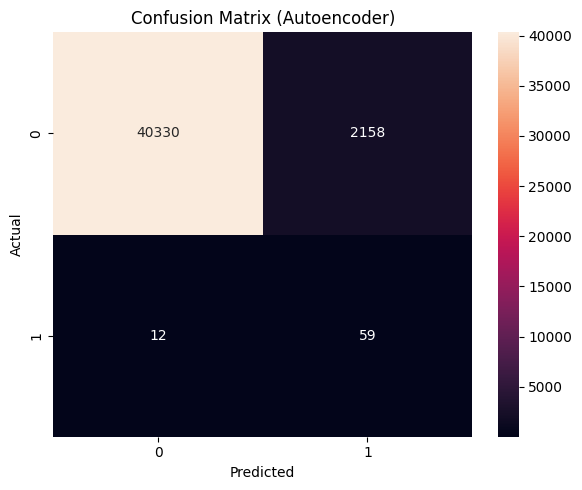

In [38]:
cm_ae = confusion_matrix(y_test_new, y_pred_ae)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ae, annot=True, fmt="d")
plt.title("Confusion Matrix (Autoencoder)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

ROC curve

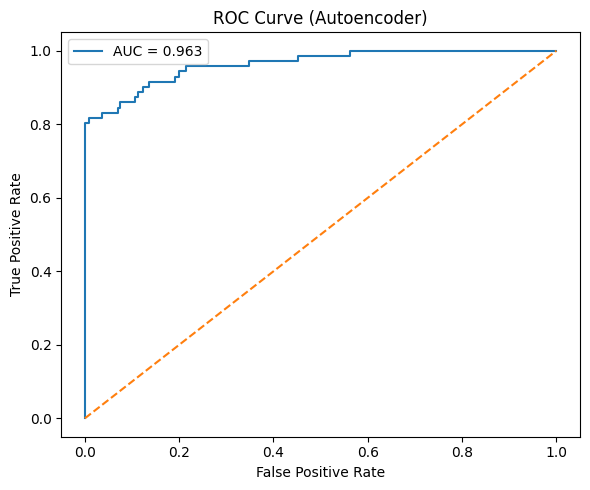

In [39]:
fpr_ae, tpr_ae, _ = roc_curve(y_test_new, mse)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ae, tpr_ae, label=f"AUC = {roc_auc_score(y_test_new, mse):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (Autoencoder)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

LSTM Model

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

Preparing LSTM dataset

In [42]:
df_lstm = df_new.copy()
df_lstm = df_lstm.sort_values("Time").reset_index(drop=True)

X_lstm = df_lstm.drop(columns=["Class", "Amount_capped"], errors="ignore")
y_lstm = df_lstm["Class"]

# Clean bad values
X_lstm = X_lstm.replace([np.inf, -np.inf], np.nan)
X_lstm = X_lstm.fillna(X_lstm.median(numeric_only=True))

print("LSTM input shape before scaling:", X_lstm.shape)
print("LSTM target shape:", y_lstm.shape)

LSTM input shape before scaling: (283726, 43)
LSTM target shape: (283726,)


Scaling the LSTM features

In [43]:
scaler_lstm = StandardScaler()
X_lstm_scaled = scaler_lstm.fit_transform(X_lstm)

print("Scaled LSTM data shape:", X_lstm_scaled.shape)

Scaled LSTM data shape: (283726, 43)


Creating Sequences

In [44]:
def create_sequences(X, y, seq_length=5):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y.iloc[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

SEQ_LENGTH = 5

X_seq, y_seq = create_sequences(
    pd.DataFrame(X_lstm_scaled),
    y_lstm,
    seq_length=SEQ_LENGTH
)

print("Sequence X shape:", X_seq.shape)
print("Sequence y shape:", y_seq.shape)

Sequence X shape: (283721, 5, 43)
Sequence y shape: (283721,)


Splitting into training, validation and testing sets

In [45]:
split_idx = int(len(X_seq) * 0.70)
val_idx = int(len(X_seq) * 0.85)

X_train_seq = X_seq[:split_idx]
y_train_seq = y_seq[:split_idx]

X_val_seq = X_seq[split_idx:val_idx]
y_val_seq = y_seq[split_idx:val_idx]

X_test_seq = X_seq[val_idx:]
y_test_seq = y_seq[val_idx:]

print("LSTM Train shape:", X_train_seq.shape)
print("LSTM Validation shape:", X_val_seq.shape)
print("LSTM Test shape:", X_test_seq.shape)

LSTM Train shape: (198604, 5, 43)
LSTM Validation shape: (42558, 5, 43)
LSTM Test shape: (42559, 5, 43)


Handling the class imbalance using class weights

In [46]:
classes = np.unique(y_train_seq)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)

class_weight_dict = {int(classes[i]): class_weights[i] for i in range(len(classes))}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.5009231327999677), 1: np.float64(271.3169398907104)}


Building the LSTM model

In [47]:
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,761 (116.25 KB)

 Trainable params: 29,761 (116.25 KB)

 Non-trainable params: 0 (0.00 B)

Training the LSTM

In [48]:
early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.7166 - loss: 0.6680 - val_accuracy: 0.9980 - val_loss: 0.3259
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6448 - loss: 0.6303 - val_accuracy: 0.9640 - val_loss: 0.3567
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6396 - loss: 0.6053 - val_accuracy: 0.8982 - val_loss: 0.3514
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6709 - loss: 0.5699 - val_accuracy: 0.9653 - val_loss: 0.1822
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6831 - loss: 0.5379 - val_accuracy: 0.9092 - val_loss: 0.2390
Epoch 6/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7161 - loss: 0.4888 - val_accuracy: 0.9506 - val_loss: 0.1284
Epoch 7/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7491 - loss: 0.4294 - val_accuracy: 0.9265 - val_loss: 0.1528
Epoch 8/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7663 - loss: 0.3994 - 

Plotting the training Loss

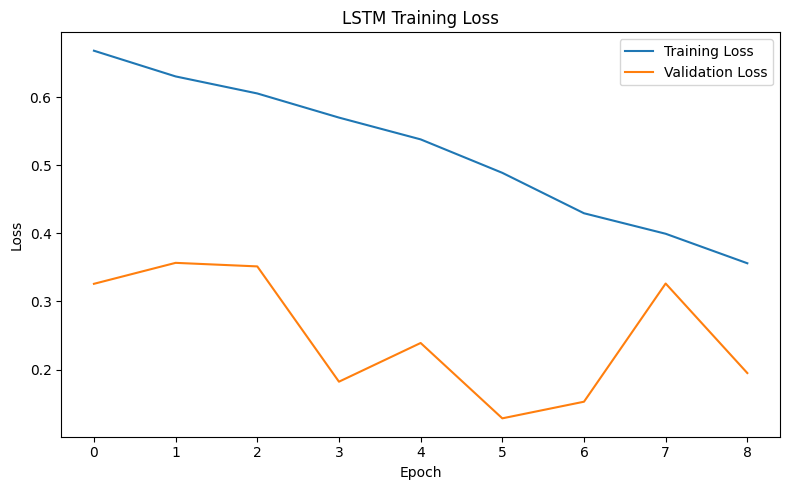

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Evaluate the LSTM

In [50]:
y_prob_lstm = lstm_model.predict(X_test_seq).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("Confusion Matrix (LSTM):")
print(confusion_matrix(y_test_seq, y_pred_lstm))

print("\nClassification Report (LSTM):")
print(classification_report(y_test_seq, y_pred_lstm))

print("\nROC-AUC Score:")
lstm_auc = roc_auc_score(y_test_seq, y_prob_lstm)
print(lstm_auc)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Confusion Matrix (LSTM):
[[40642  1865]
 [   49     3]]

Classification Report (LSTM):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     42507
           1       0.00      0.06      0.00        52

    accuracy                           0.96     42559
   macro avg       0.50      0.51      0.49     42559
weighted avg       1.00      0.96      0.98     42559


ROC-AUC Score:
0.5249881919900976


Confusion matrix

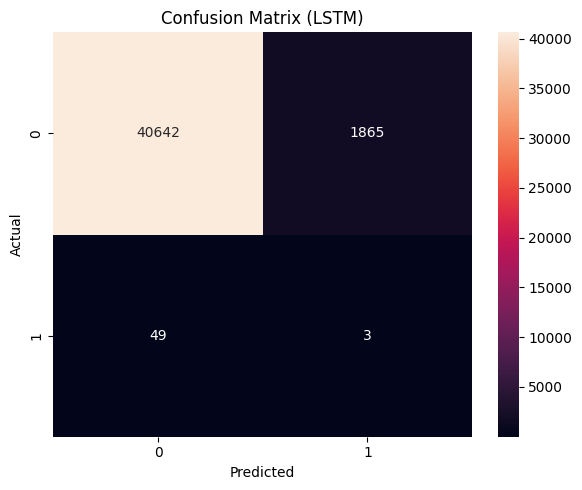

In [51]:
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt="d")
plt.title("Confusion Matrix (LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

ROC curve

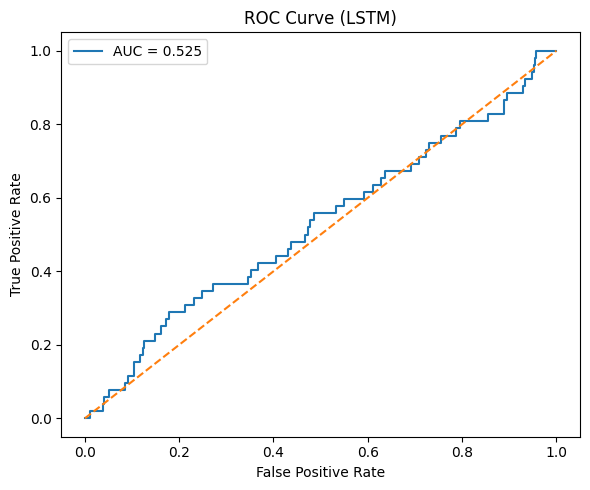

In [52]:
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, y_prob_lstm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lstm, tpr_lstm, label=f"AUC = {lstm_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (LSTM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

Final Comparision Update

In [53]:
comparison_final = pd.DataFrame({
    "Model": [
        "Enhanced Random Forest",
        "Isolation Forest",
        "LOF",
        "MLP",
        "Autoencoder",
        "LSTM"
    ],
    "ROC_AUC": [
        rf_auc,
        iso_auc,
        lof_auc,
        mlp_auc,
        roc_auc_score(y_test_new, mse),
        lstm_auc
    ]
})

comparison_final

,Model,ROC_AUC
0,Enhanced Random Forest,0.894296
1,Isolation Forest,0.632708
2,LOF,0.506218
3,MLP,0.887194
4,Autoencoder,0.962666
5,LSTM,0.524988


Final Comparison Graph

<Figure size 900x500 with 0 Axes>

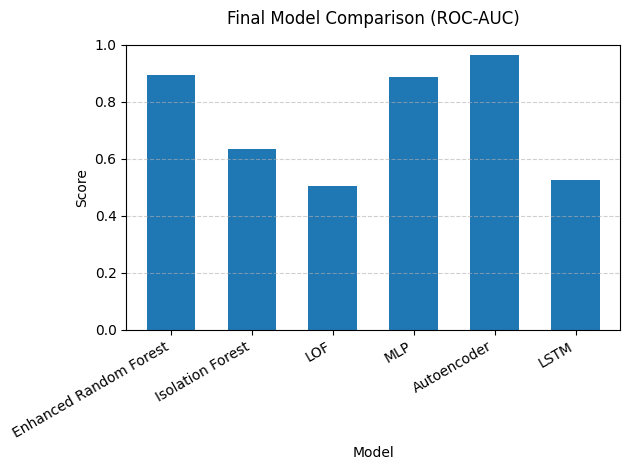

In [54]:
plt.figure(figsize=(9, 5))

comparison_final.set_index("Model").plot(
    kind="bar",
    legend=False,
    width=0.6
)

plt.title("Final Model Comparison (ROC-AUC)", pad=15)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()